In [25]:
import pandas as pd


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [35]:
train = pd.read_csv("data/baseline_modeling/baseline_train_model_ready.csv")
val = pd.read_csv("data/baseline_modeling/baseline_val_model_ready.csv")
test = pd.read_csv("data/baseline_modeling/baseline_test_model_ready.csv")


In [37]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   checkpoint                1896 non-null   str    
 1   position                  1896 non-null   str    
 2   is_home                   1896 non-null   bool   
 3   formation                 1896 non-null   str    
 4   subbed                    1896 non-null   bool   
 5   last15_sprints            1896 non-null   int64  
 6   last15_hsr                1896 non-null   int64  
 7   last15_distance           1896 non-null   float64
 8   last15_mean_max_speed     1896 non-null   float64
 9   last15_peak_speed         1896 non-null   float64
 10  last15_shots              1896 non-null   int64  
 11  last15_shots_on_target    1896 non-null   int64  
 12  last15_shots_under_press  1896 non-null   int64  
 13  last15_shots_top_third    1896 non-null   int64  
 14  cumul_sprints      

In [39]:
target = "scored_after"

X_train_df = train.drop(columns=[target]).copy()
y_train = train[target].copy()

X_val_df = val.drop(columns=[target]).copy()
y_val = val[target].copy()

X_test_df = test.drop(columns=[target]).copy()
y_test = test[target].copy()

cat_cols = X_train_df.select_dtypes(include=["object", "category", "string"]).columns.to_list()
num_cols = X_train_df.select_dtypes(include=["number", "bool"]).columns.to_list()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['checkpoint', 'position', 'formation']
Numeric: ['is_home', 'subbed', 'last15_sprints', 'last15_hsr', 'last15_distance', 'last15_mean_max_speed', 'last15_peak_speed', 'last15_shots', 'last15_shots_on_target', 'last15_shots_under_press', 'last15_shots_top_third', 'cumul_sprints', 'cumul_hsr', 'cumul_distance', 'cumul_mean_max_speed', 'cumul_peak_speed', 'cumul_shots', 'cumul_shots_on_target', 'cumul_shots_under_press', 'cumul_shots_top_third', 'cumul_in_game_time', 'last_15_received_succ', 'last_15_received_unsucc', 'cumul_received_succ', 'cumul_received_unsucc']


In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [43]:
tree_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=42
    ))
])

In [45]:
tree_pipe.fit(X_train_df, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [47]:
y_val_pred = tree_pipe.predict(X_val_df)
y_val_prob = tree_pipe.predict_proba(X_val_df)[:, 1]

val_acc = accuracy_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_prob)

print("Validation accuracy:", val_acc)
print("Validation ROC AUC:", val_auc)
print(classification_report(y_val, y_val_pred))

Validation accuracy: 0.9282442748091603
Validation ROC AUC: 0.6777265287903586
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       611
           1       0.00      0.00      0.00        44

    accuracy                           0.93       655
   macro avg       0.47      0.50      0.48       655
weighted avg       0.87      0.93      0.90       655



In [49]:
y_test_pred = tree_pipe.predict(X_test_df)
y_test_prob = tree_pipe.predict_proba(X_test_df)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Test accuracy:", test_acc)
print("Test ROC AUC:", test_auc)

Test accuracy: 0.9494470774091627
Test ROC AUC: 0.7580783283854762


                          feature  mean_abs_shap
0                 cat__position_A       0.025857
1      num__cumul_received_unsucc       0.019092
2            num__last15_distance       0.011961
3           num__cumul_peak_speed       0.010585
4                     num__subbed       0.010002
5             num__cumul_distance       0.009850
6                  num__cumul_hsr       0.005969
7          cat__formation_4-2-3-1       0.005572
8         num__cumul_in_game_time       0.004851
9      num__last_15_received_succ       0.004814
10  num__last15_shots_under_press       0.000000
11    num__last15_shots_on_target       0.000000
12              num__last15_shots       0.000000
13         num__last15_peak_speed       0.000000
14     num__last15_mean_max_speed       0.000000
15                num__last15_hsr       0.000000
16            num__last15_sprints       0.000000
17                   num__is_home       0.000000
18     num__cumul_shots_on_target       0.000000
19               num

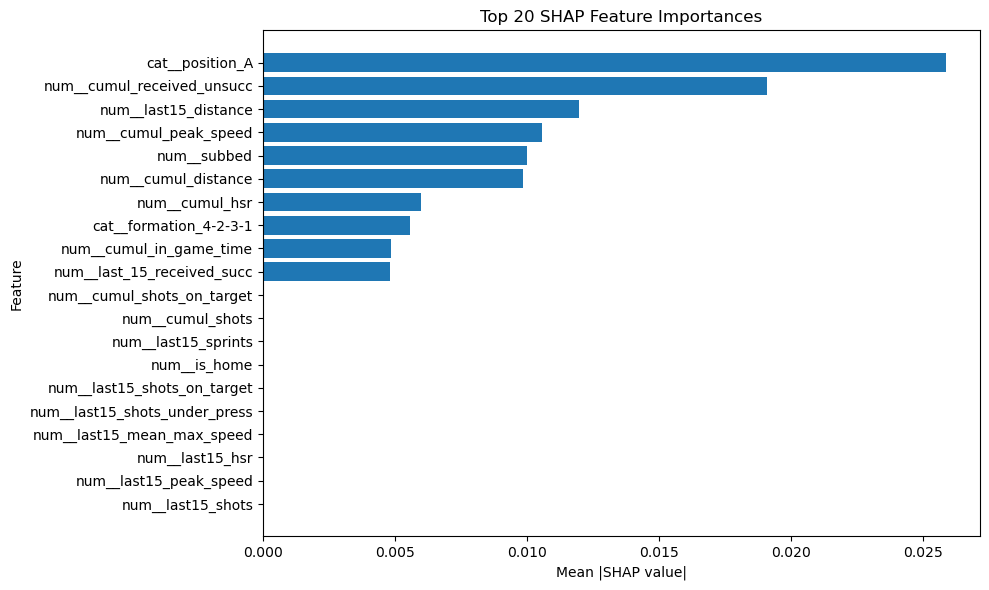

In [53]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# fitted objects from your pipeline
preprocessor_fitted = tree_pipe.named_steps["preprocessor"]
tree_model = tree_pipe.named_steps["model"]

# transform validation data
X_val_transformed = preprocessor_fitted.transform(X_val_df)

# convert sparse matrix to dense if needed
if hasattr(X_val_transformed, "toarray"):
    X_val_transformed = X_val_transformed.toarray()

# transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# dataframe for readability
X_val_transformed_df = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val_df.index
)

# compute SHAP values
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_val_transformed_df)

# make SHAP output consistently 2D: (n_samples, n_features)
if isinstance(shap_values, list):
    # older SHAP: list of arrays, take positive class
    shap_values_2d = np.array(shap_values[1])
else:
    shap_values_2d = np.array(shap_values)

    # possible shapes:
    # (n_samples, n_features)
    # (n_samples, n_features, 2)
    # (n_samples, 2, n_features)
    if shap_values_2d.ndim == 3:
        if shap_values_2d.shape[2] == 2:
            # shape: (n_samples, n_features, n_classes)
            shap_values_2d = shap_values_2d[:, :, 1]
        elif shap_values_2d.shape[1] == 2:
            # shape: (n_samples, n_classes, n_features)
            shap_values_2d = shap_values_2d[:, 1, :]

# mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values_2d).mean(axis=0)

# importance table
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(shap_importance.head(20))

# histogram-style importance plot (horizontal bar chart)
top_n = 20
plot_df = shap_importance.head(top_n).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"Top {top_n} SHAP Feature Importances")
plt.tight_layout()
plt.show()

In [65]:
to_drop = ['position', 'cumul_received_unsucc', 'last15_distance', 
          'cumul_peak_speed', 'subbed', 'cumul_distance', 'cumul_hsr', 
          'formation']

In [67]:
train = train.drop(columns = to_drop)
val = val.drop(columns = to_drop)
test = test.drop(columns = to_drop)

In [69]:
target = "scored_after"

X_train_df = train.drop(columns=[target]).copy()
y_train = train[target].copy()

X_val_df = val.drop(columns=[target]).copy()
y_val = val[target].copy()

X_test_df = test.drop(columns=[target]).copy()
y_test = test[target].copy()

cat_cols = X_train_df.select_dtypes(include=["object", "category", "string"]).columns.to_list()
num_cols = X_train_df.select_dtypes(include=["number", "bool"]).columns.to_list()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['checkpoint']
Numeric: ['is_home', 'last15_sprints', 'last15_hsr', 'last15_mean_max_speed', 'last15_peak_speed', 'last15_shots', 'last15_shots_on_target', 'last15_shots_under_press', 'last15_shots_top_third', 'cumul_sprints', 'cumul_mean_max_speed', 'cumul_shots', 'cumul_shots_on_target', 'cumul_shots_under_press', 'cumul_shots_top_third', 'cumul_in_game_time', 'last_15_received_succ', 'last_15_received_unsucc', 'cumul_received_succ']
